In [1]:
import pandas as pd

csv= pd.read_csv('/media/Volume/data/MIMIC_IV/discharge.csv.gz')
print(csv.head())
# print unique subject IDs
unique_subject_ids = csv['subject_id'].unique()
print("Unique subject IDs in discharge.csv:", len(unique_subject_ids))

# total len
print("Total number of ecgs:", len(csv))

          note_id  subject_id   hadm_id note_type  note_seq  \
0  10000032-DS-21    10000032  22595853        DS        21   
1  10000032-DS-22    10000032  22841357        DS        22   
2  10000032-DS-23    10000032  29079034        DS        23   
3  10000032-DS-24    10000032  25742920        DS        24   
4  10000084-DS-17    10000084  23052089        DS        17   

             charttime            storetime  \
0  2180-05-07 00:00:00  2180-05-09 15:26:00   
1  2180-06-27 00:00:00  2180-07-01 10:15:00   
2  2180-07-25 00:00:00  2180-07-25 21:42:00   
3  2180-08-07 00:00:00  2180-08-10 05:43:00   
4  2160-11-25 00:00:00  2160-11-25 15:09:00   

                                                text  
0   \nName:  ___                     Unit No:   _...  
1   \nName:  ___                     Unit No:   _...  
2   \nName:  ___                     Unit No:   _...  
3   \nName:  ___                     Unit No:   _...  
4   \nName:  ___                    Unit No:   __...  
Unique s

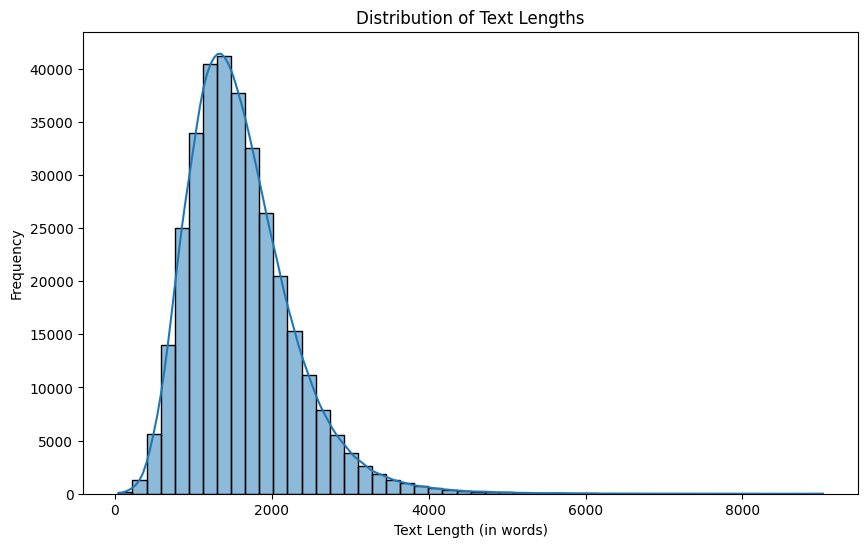

In [5]:
# get the max lenght of the text and make a histplot
import matplotlib.pyplot as plt
import seaborn as sns
csv['text_length'] = csv['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(csv['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length (in words)')
plt.ylabel('Frequency')
plt.show()


In [8]:
# print first text entry
print("First text entry:", csv['text'].iloc[38])

First text entry:  
Name:  ___              Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
No Known Allergies / Adverse Drug Reactions
 
Attending: ___.
 
Chief Complaint:
Hematuria, weakness
 
Major Surgical or Invasive Procedure:
None

 
History of Present Illness:
___ y/o female with h/o PE (on lovenox), bladder cancer s/p  
Robotic TAH-BSO, lap radical cystectomy with ileal loop 
diversion and anterior vaginectomy in ___ c/b abdominal 
fluid requiring placement of drainage catheters. Recent 
abdominal imaging noted worsening of her bilateral severe 
hydronephrosis and her Cr was noted to have risen from 0.8 to 
1.3(outside lab value). Patient recently underwent bilateral 
nephrostomy tube placement by ___ on ___.

She first started feeling weak during ___ yesterday doing the 
exercises. Had palpitations with ambulation. Has tightness in 
chest with ambulating since yesterday. Felt

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import pandas as pd

# Choose a light model
model_id = "google/gemma-2-9b-it"

# Load tokenizer and model (4-bit quantized)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="cuda",
    torch_dtype=torch.float16,
    load_in_4bit=True  # needs bitsandbytes
)
for i, text in enumerate(csv["text"]):
    prompt = f"""Extract only the LVEF value (number or range) from the text, for example:
    ... LVEF>55%   --> >55
    Doppler elt his LVEF was ~30% and reduced ...  --> 30
    HFpEF (LVEF 50% ___, PAD, CKD (stage IV), prior DVT c/b severe --> 50
    Her TTE showed mild-moderate mitral and moderate tricuspid regurgitation, LVEF 50-55%, and pulmonary hypertension. --> 50-55

    if no LVEF value is found, return "unknown".
    text: {text}
    
    Answer: The LVEF value is:"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=15)
        print(outputs)

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = decoded.replace(prompt, "").strip()
    print(f"Row {i}: {answer}")
    csv.at[i, 'lvef'] = answer

# for each row in the dataframe, generate LVEF value

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# save the dataframe to a new CSV file
csv.to_csv('/media/Volume/data/MIMIC_IV/discharge_lvef.csv')

